In [1]:
import sys
from pathlib import Path

# sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))
sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle

In [49]:
# example_posdf = pd.read_csv(r'pos_dfs\0_circular_layout.csv')
# with open('graph_objects\graph_0.pkl', 'rb') as f:
#     G = pickle.load(f)

In [50]:
# zrobic df gdzie jest: graph_id+layout(czyli nazwa pliku), score, i oliczone wartosci kazdego z komponentow

# MAIN LOOP

In [2]:

# annotations = pd.read_excel('randoms_ER_annotations_scores.xlsx')
annotations = pd.read_excel('randoms_SBM_annotations_scores_wo_lgl.xlsx')

In [3]:
import os 
posdf_dir = 'pos_dfs'
graph_dir = 'graph_objects'


calculated_components_df = pd.DataFrame(columns=['posdf_id', 'score', 
                                                 'node_distribution', 'node_distribution_raw', 
                                                 'distance_to_borderlines', 'distance_to_borderlines_raw', 
                                                 'edge_length_sum', 'edge_length_sum_raw', 
                                                 'edge_node_distance_contribution','edge_node_distance_contribution_raw', 
                                                 'count_edge_crossings',  'count_edge_crossings_raw',
                                                 'communities_closeness', 'sum_of_angles', 'symmetry'])

# Iterate through files in the posdf_dir
skip_layouts = ['lgl']


for posdf_file in os.listdir(posdf_dir):

    if posdf_file.split('_')[1].split('.')[0] not in skip_layouts:
        # reading data

        if posdf_file.endswith('.csv'):
            posdf = pd.read_csv(os.path.join(posdf_dir, posdf_file))
            print(f'Loaded {posdf_file}')

        graph_id = posdf_file.split('_')[0]
        layout = posdf_file.split('.')[0]
        layout = layout[2:]
        score = annotations[annotations['graph_id'] == int(graph_id)][layout].values[0]


        graph_file = 'graph_'+graph_id+'.pkl' 
        with open(os.path.join(graph_dir, graph_file), 'rb') as f:
            G = pickle.load(f)
        components_dict = {
            'posdf_id': posdf_file,
            'score': score,
            'node_distribution': node_distribution(posdf),
            'node_distribution_raw': node_distribution_raw(posdf),
            'distance_to_borderlines': distance_to_borderlines(posdf),
            'distance_to_borderlines_raw': distance_to_borderlines_raw(posdf),
            'edge_length_sum': edge_length_sum(G, posdf),
            'edge_length_sum_raw': edge_length_sum_raw(G, posdf),
            'edge_node_distance_contribution': edge_node_distance_contribution(G, posdf)[0],
            'edge_node_distance_contribution_raw': edge_node_distance_contribution_raw(G, posdf)[0],

            'count_edge_crossings': count_edge_crossings(G, posdf),
            'count_edge_crossings_raw': count_edge_crossings_raw(G, posdf),

            'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
            'sum_of_angles' : sum_of_angles(G, posdf),
            'symmetry' : measure_graph_symmetry(G, posdf)
        }
        new_row_df = pd.DataFrame([components_dict])
        calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)

Loaded 0_kamada_kawai.csv


C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_4320\2188707839.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)


Loaded 0_random_no1.csv
Loaded 0_random_no2.csv
Loaded 0_random_no3.csv
Loaded 0_random_no4.csv
Loaded 0_random_no5.csv
Loaded 1_kamada_kawai.csv
Loaded 1_random_no1.csv
Loaded 1_random_no2.csv
Loaded 1_random_no3.csv
Loaded 1_random_no4.csv
Loaded 1_random_no5.csv
Loaded 2_kamada_kawai.csv
Loaded 2_random_no1.csv
Loaded 2_random_no2.csv
Loaded 2_random_no3.csv
Loaded 2_random_no4.csv
Loaded 2_random_no5.csv
Loaded 3_kamada_kawai.csv
Loaded 3_random_no1.csv
Loaded 3_random_no2.csv
Loaded 3_random_no3.csv
Loaded 3_random_no4.csv
Loaded 3_random_no5.csv
Loaded 4_kamada_kawai.csv
Loaded 4_random_no1.csv
Loaded 4_random_no2.csv
Loaded 4_random_no3.csv
Loaded 4_random_no4.csv
Loaded 4_random_no5.csv
Loaded 5_kamada_kawai.csv
Loaded 5_random_no1.csv
Loaded 5_random_no2.csv
Loaded 5_random_no3.csv
Loaded 5_random_no4.csv
Loaded 5_random_no5.csv
Loaded 6_kamada_kawai.csv
Loaded 6_random_no1.csv
Loaded 6_random_no2.csv
Loaded 6_random_no3.csv
Loaded 6_random_no4.csv
Loaded 6_random_no5.csv
Load

In [4]:
calculated_components_df.head(10)

,posdf_id,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry
0,0_kamada_kawai.csv,6,63.889790,48.927700,115282.697,452.474,6.812397,10.261332,266.889735,167.788146,4,2,16.310859,15.350237,0.916253
1,0_random_no1.csv,5,381.565351,92.910606,1890.138,113.349,7.065569,9.964739,4482.555909,474.118142,400,20,14.185531,15.721607,0.977142
2,0_random_no2.csv,4,1685.107060,133.823901,3263.852,87.165,4.820243,7.859177,19706.027958,721.737654,121,11,11.494020,15.127102,0.970546
3,0_random_no3.csv,1,2351.293052,158.879750,5685.020,104.198,3.367168,6.350921,22821.207360,827.163752,9,3,9.335205,15.151705,0.971678
4,0_random_no4.csv,2,1138.821903,163.957294,38.410,30.644,3.163266,6.824529,255050.294571,1757.737209,441,21,8.686502,15.584876,0.984683
5,0_random_no5.csv,3,418.367973,109.118063,4316.506,127.201,7.574127,9.873327,20377.405393,826.528411,484,22,12.997890,14.323622,0.979024
6,1_kamada_kawai.csv,6,69.191502,45.051469,10036.740,126.103,3.864257,6.597623,238.067843,123.078441,4,2,14.317652,8.645339,0.928177
7,1_random_no1.csv,1,552.418670,105.398743,222.350,49.422,3.076790,5.672086,54158.984740,809.102991,121,11,9.276913,8.309803,0.971852
8,1_random_no2.csv,5,171.143723,71.321888,548.016,55.227,4.488570,6.837693,1377.812506,265.393306,144,12,10.240764,8.380618,0.992290
9,1_random_no3.csv,4,240.866389,83.370853,4913.193,125.375,4.249399,6.714530,3181.213214,347.252458,225,15,8.597874,8.223503,0.981113


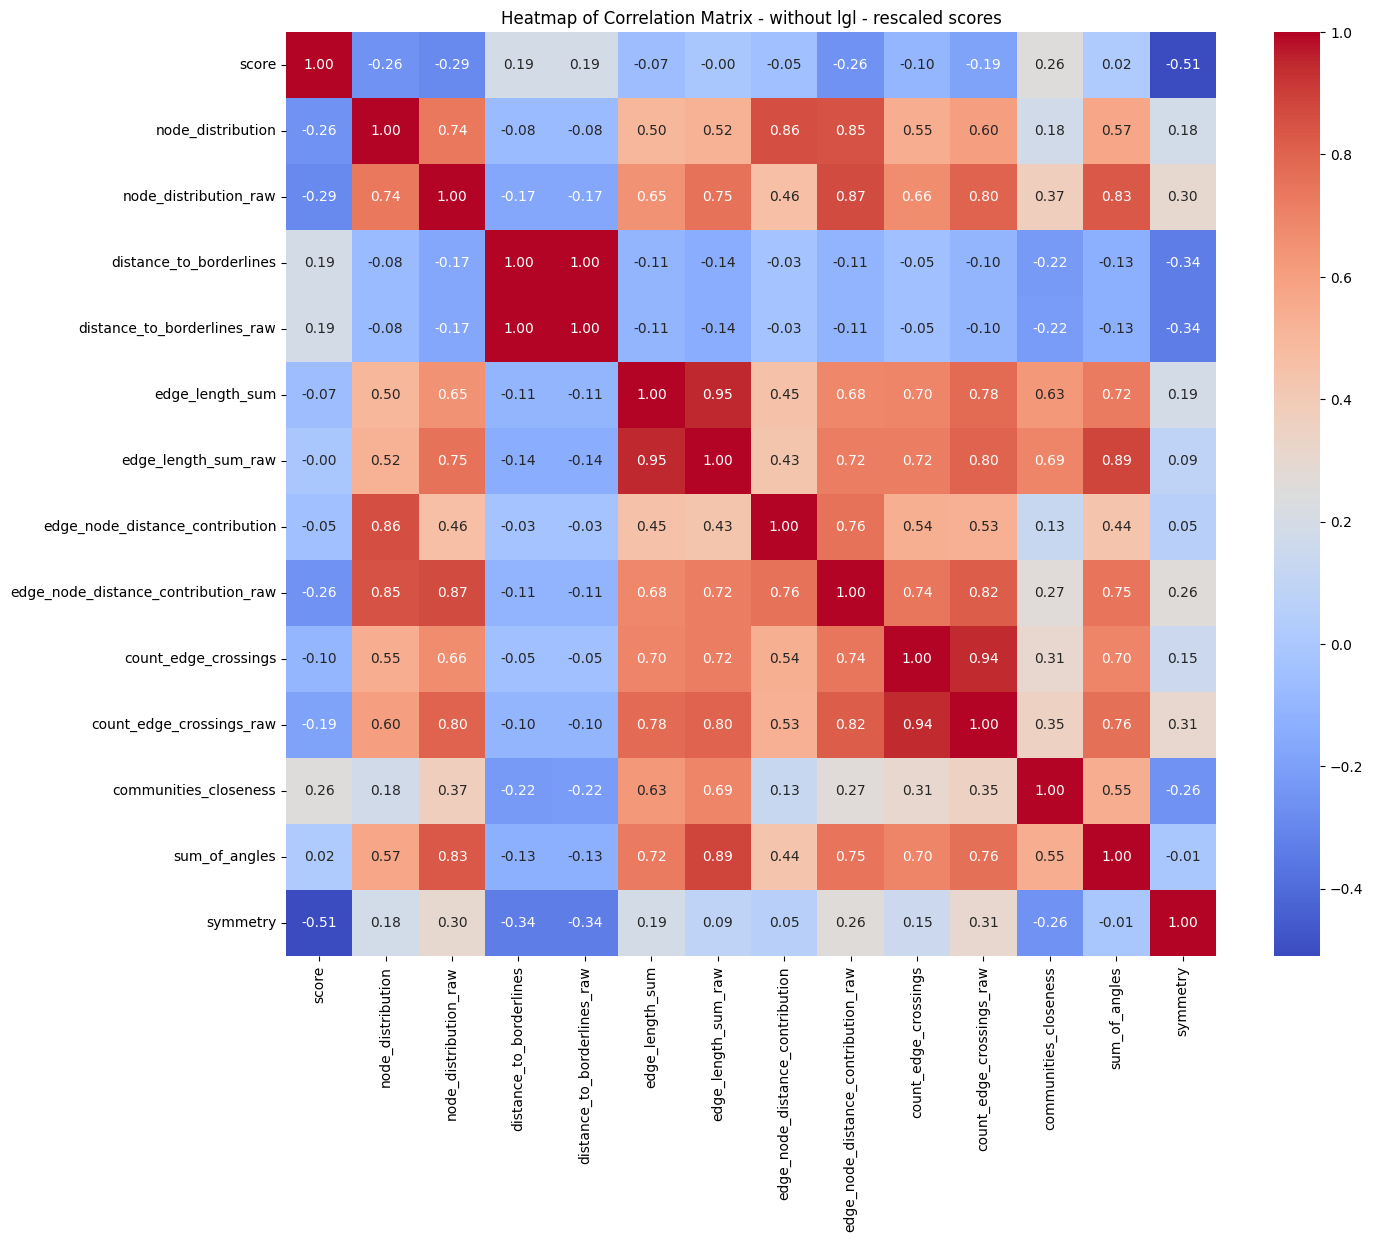

In [5]:
# Calculate the correlation matrix
# WITHOUT davidson harel
import seaborn as sns

calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])
correlation_matrix = calculated_components_df_numeric.corr()

# Generate a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Correlation Matrix - without lgl - rescaled scores')
plt.show()

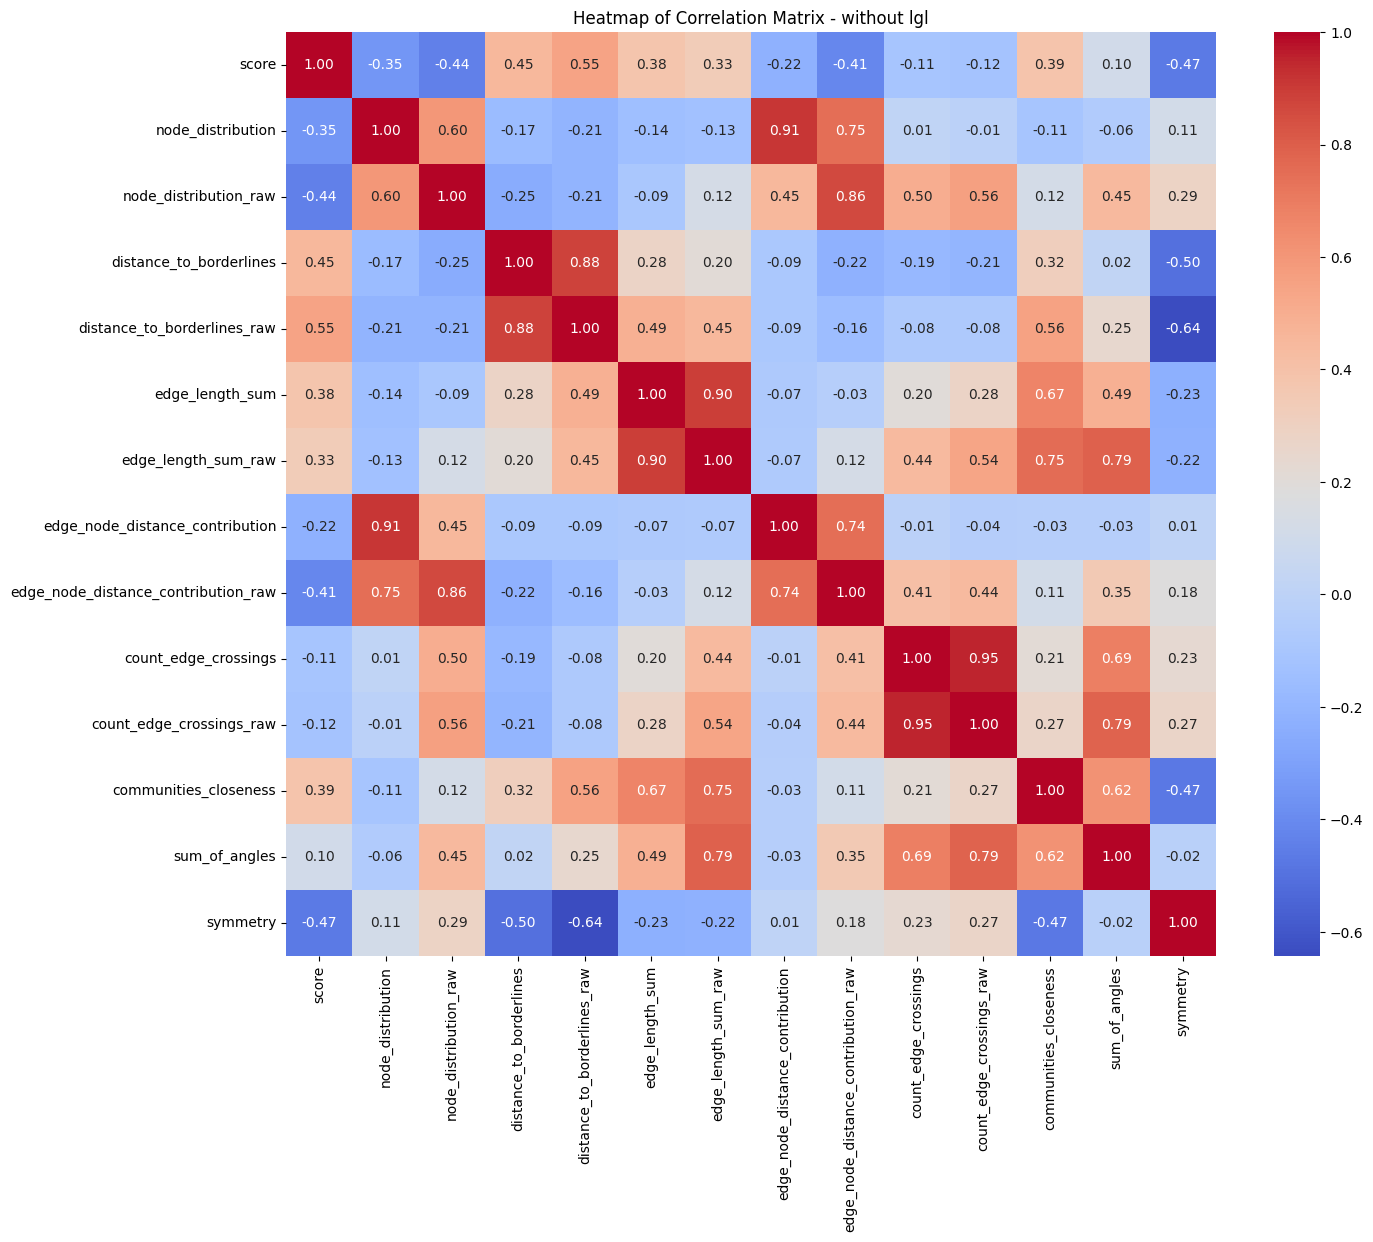

In [11]:
# Calculate the correlation matrix
# WITHOUT lgl
import seaborn as sns

calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])
correlation_matrix = calculated_components_df_numeric.corr()

# Generate a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Correlation Matrix - without lgl')
plt.show()

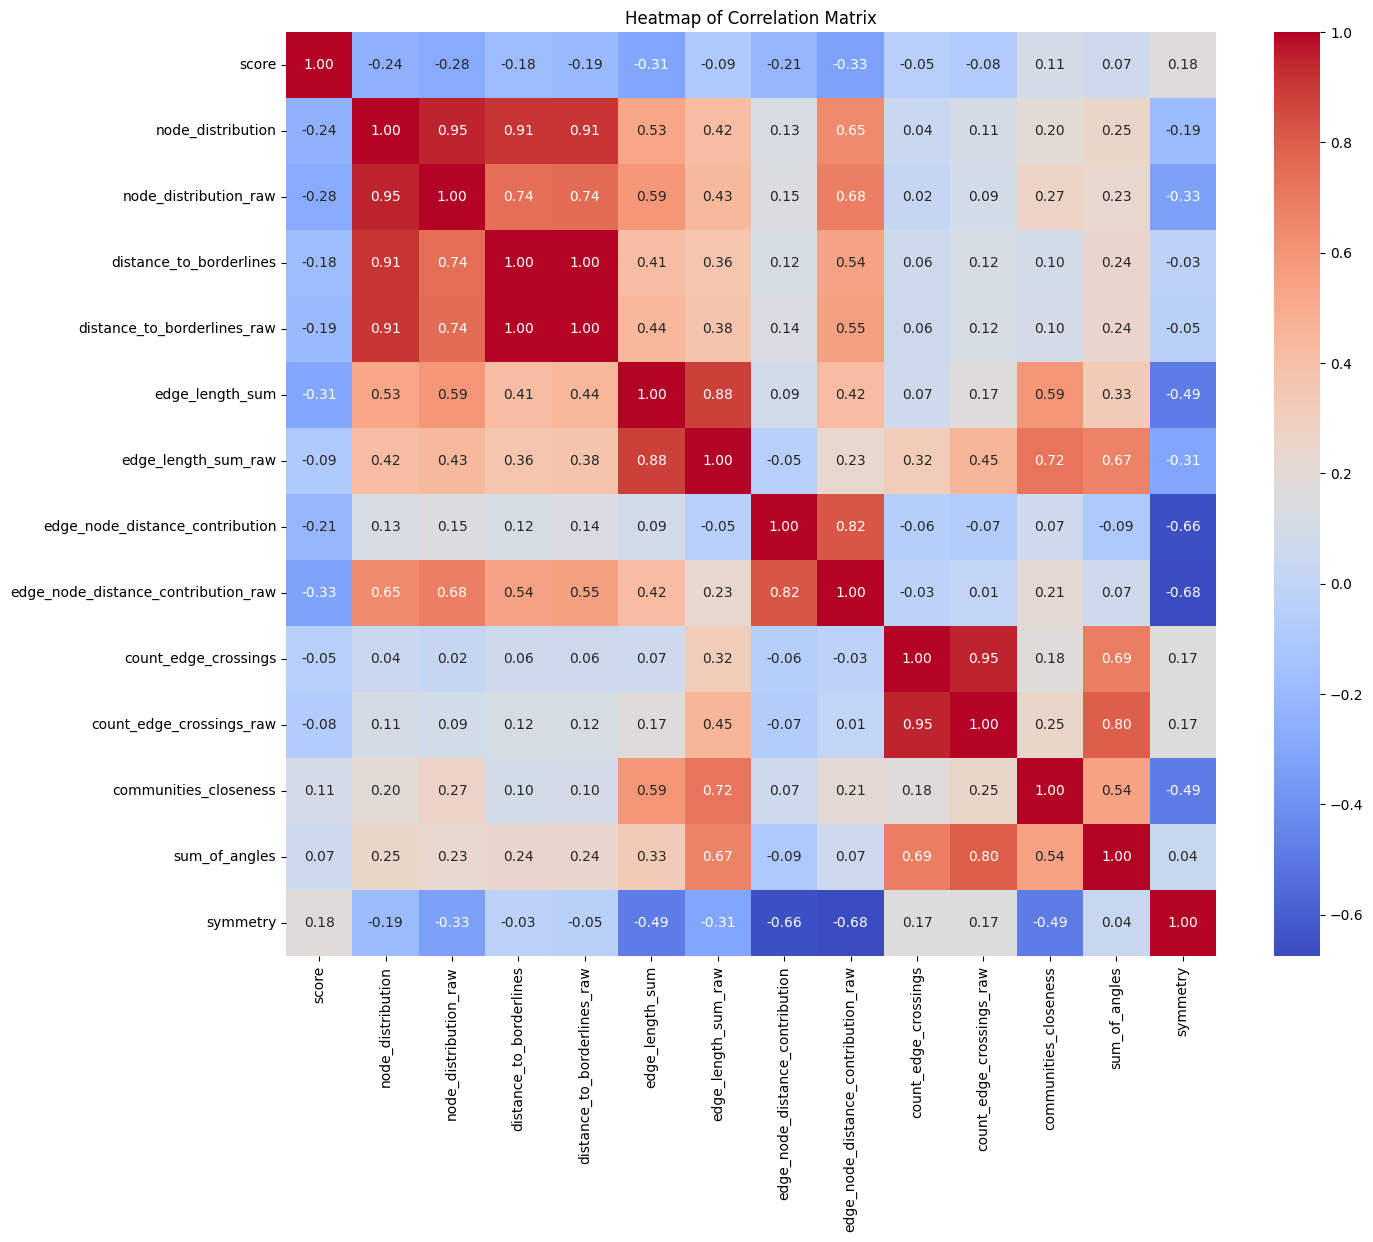

In [6]:
# Calculate the correlation matrix
# WITHOUT davidson harel
import seaborn as sns

calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])
correlation_matrix = calculated_components_df_numeric.corr()

# Generate a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Correlation Matrix')
plt.show()

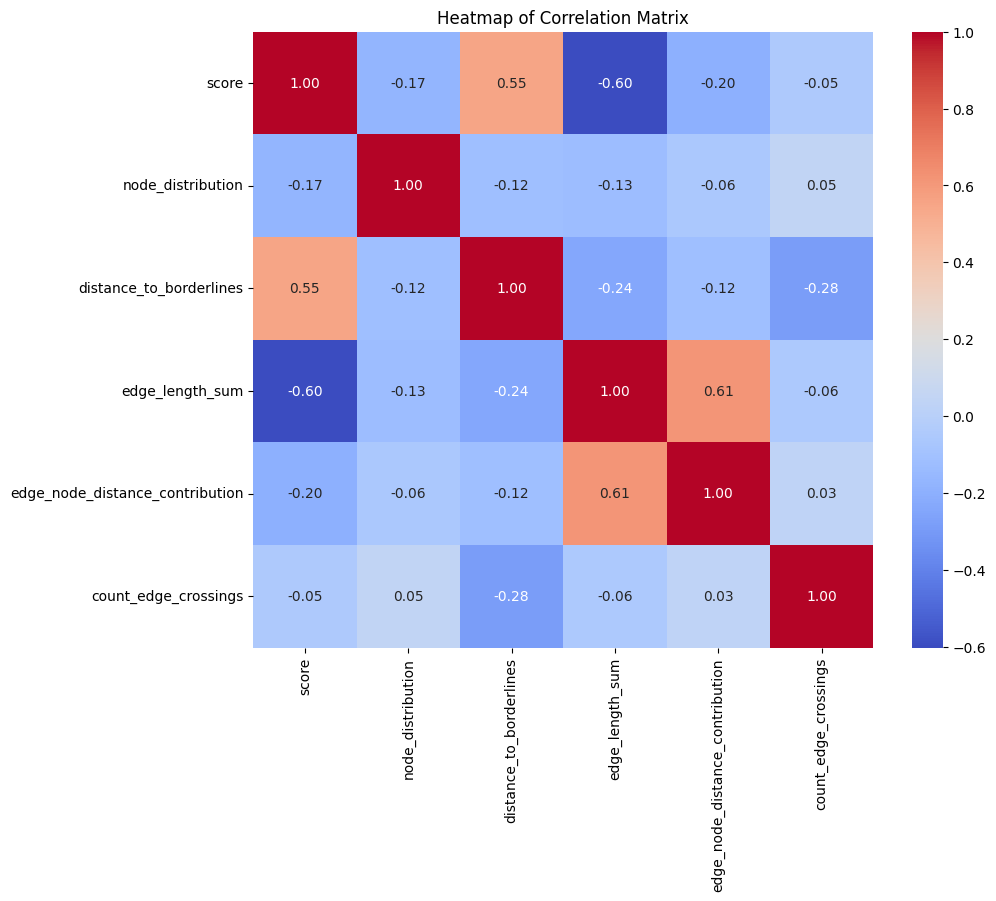

In [5]:
# Calculate the correlation matrix
# with davidson harel
import seaborn as sns

calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])
correlation_matrix = calculated_components_df_numeric.corr()

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Correlation Matrix')
plt.show()